# IMPORT LIBRARY

In [113]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# LOAD DATASET

## IMPORT ALL DATASETS FROM CSV

In [114]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
test_target = pd.read_csv('gender_submission.csv')


## SHOW ALL DATASETS INFO

In [115]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 118.9 KB


In [116]:
test.info()

<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    str    
 3   Sex          418 non-null    str    
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    str    
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     str    
 10  Embarked     418 non-null    str    
dtypes: float64(2), int64(4), str(5)
memory usage: 52.8 KB


In [117]:
test_target.info()

<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   PassengerId  418 non-null    int64
 1   Survived     418 non-null    int64
dtypes: int64(2)
memory usage: 6.7 KB


## MERGE ALL DATASETS TO DATAFRAME

In [118]:
y = pd.concat([train['Survived'], test_target['Survived']])

train = train.drop('Survived', axis=1)
x = pd.concat([train, test])

df = pd.concat([x, y], axis=1)
df.info()

<class 'pandas.DataFrame'>
Index: 1309 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  1309 non-null   int64  
 1   Pclass       1309 non-null   int64  
 2   Name         1309 non-null   str    
 3   Sex          1309 non-null   str    
 4   Age          1046 non-null   float64
 5   SibSp        1309 non-null   int64  
 6   Parch        1309 non-null   int64  
 7   Ticket       1309 non-null   str    
 8   Fare         1308 non-null   float64
 9   Cabin        295 non-null    str    
 10  Embarked     1307 non-null   str    
 11  Survived     1309 non-null   int64  
dtypes: float64(2), int64(5), str(5)
memory usage: 185.0 KB


# PREPROCESSING DATA

## DROP IRRELEVANT FEATURE FEATURE

In [119]:
df = df.drop(['PassengerId', 'Name', 'Ticket'], axis=1)
df.info()

<class 'pandas.DataFrame'>
Index: 1309 entries, 0 to 417
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    1309 non-null   int64  
 1   Sex       1309 non-null   str    
 2   Age       1046 non-null   float64
 3   SibSp     1309 non-null   int64  
 4   Parch     1309 non-null   int64  
 5   Fare      1308 non-null   float64
 6   Cabin     295 non-null    str    
 7   Embarked  1307 non-null   str    
 8   Survived  1309 non-null   int64  
dtypes: float64(2), int64(4), str(3)
memory usage: 110.9 KB


## HANDLE MISSING VALUE


In [120]:
# CHECK MISSING VALUES
df.isnull().sum()

Pclass         0
Sex            0
Age          263
SibSp          0
Parch          0
Fare           1
Cabin       1014
Embarked       2
Survived       0
dtype: int64

In [121]:
# HANDLE MISSING VALUES

# MENGHAPUS KOLOM DENGAN MISSING VALUE DI ATAS 25%  
df = df.drop('Cabin', axis=1)

# UNTUK KOLOM DENGAN MISSING VALUE DI BAWAH 25%

# UNTUK DATA NUMERIK, ISI MISSING VALUES DENGAN MEDIAN PADA KOLOM TERSEBUT
numerical_cols = df.drop(columns=['Survived']).select_dtypes(include='number').columns
df[numerical_cols] = df[numerical_cols].fillna(df[numerical_cols].median())

# UNTUK DATA KATEGORIKAL, ISI MISSING VALUES DENGAN MODUS PADA KOLOM TERSEBUT
categorical_cols = df.select_dtypes(include='object').columns
df[categorical_cols] = df[categorical_cols].fillna(df[categorical_cols].mode().iloc[0])

df.info()

<class 'pandas.DataFrame'>
Index: 1309 entries, 0 to 417
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    1309 non-null   int64  
 1   Sex       1309 non-null   str    
 2   Age       1309 non-null   float64
 3   SibSp     1309 non-null   int64  
 4   Parch     1309 non-null   int64  
 5   Fare      1309 non-null   float64
 6   Embarked  1309 non-null   str    
 7   Survived  1309 non-null   int64  
dtypes: float64(2), int64(4), str(2)
memory usage: 99.3 KB


C:\Users\tabiz\AppData\Local\Temp\ipykernel_1716\403898568.py:13: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include='object').columns


## HANDLE OUTLIERS

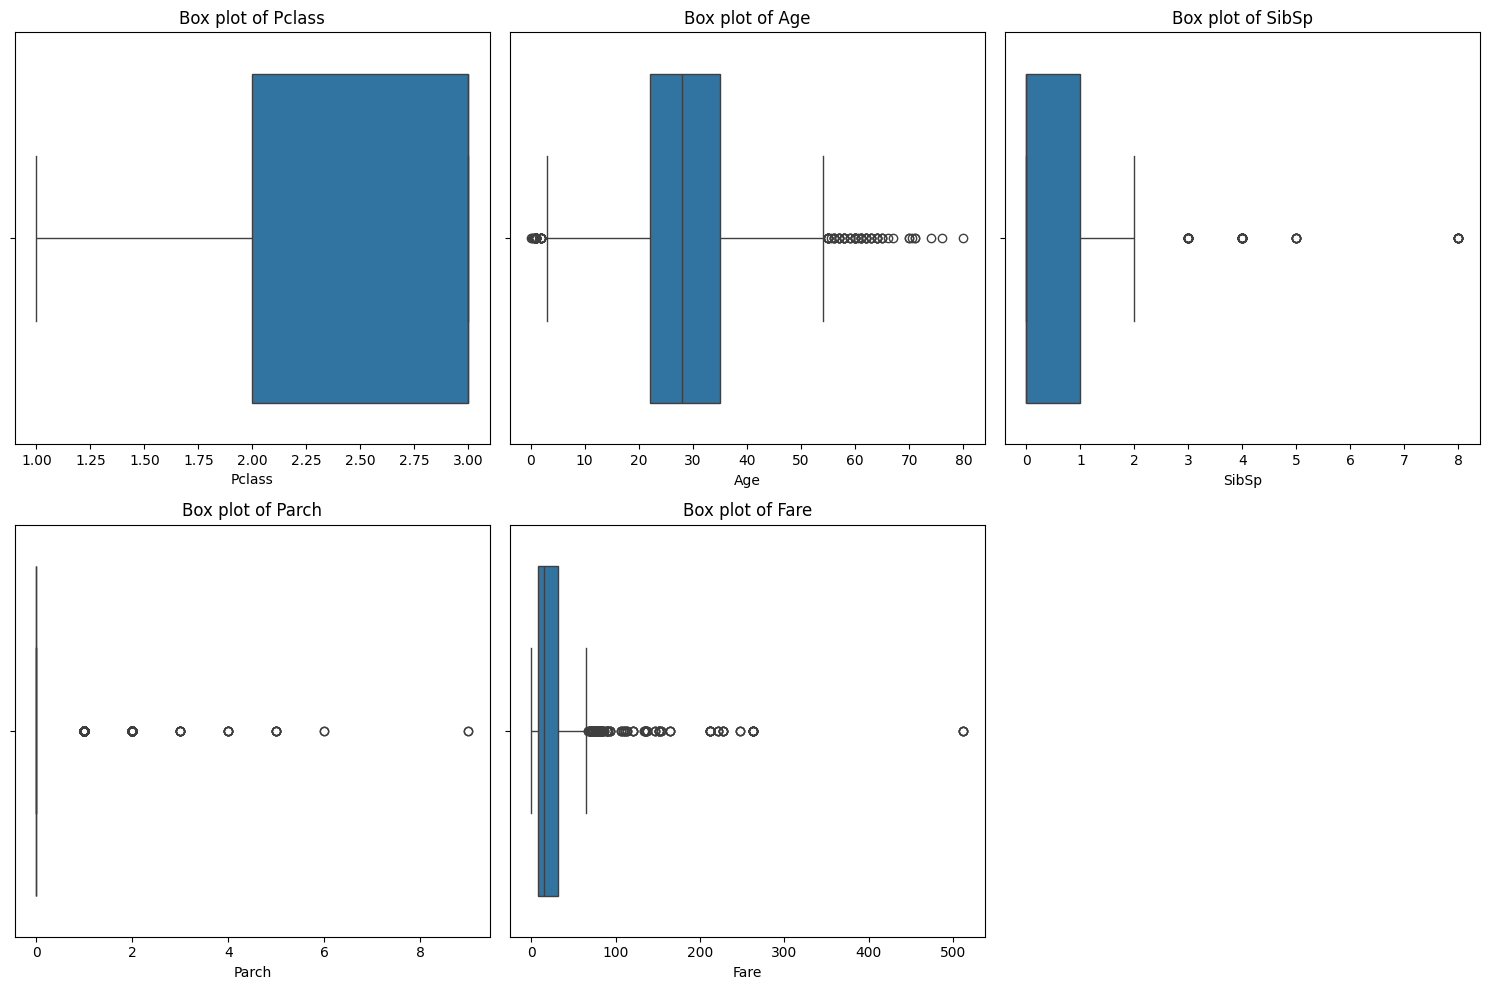

In [122]:
# BEFORE DROP OUTLIERS

plt.figure(figsize=(15, 10))
for i, column in enumerate(numerical_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x=df[column])
    plt.title(f'Box plot of {column}')
plt.tight_layout()
plt.show()

In [123]:
# DROP OUTLIERS

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

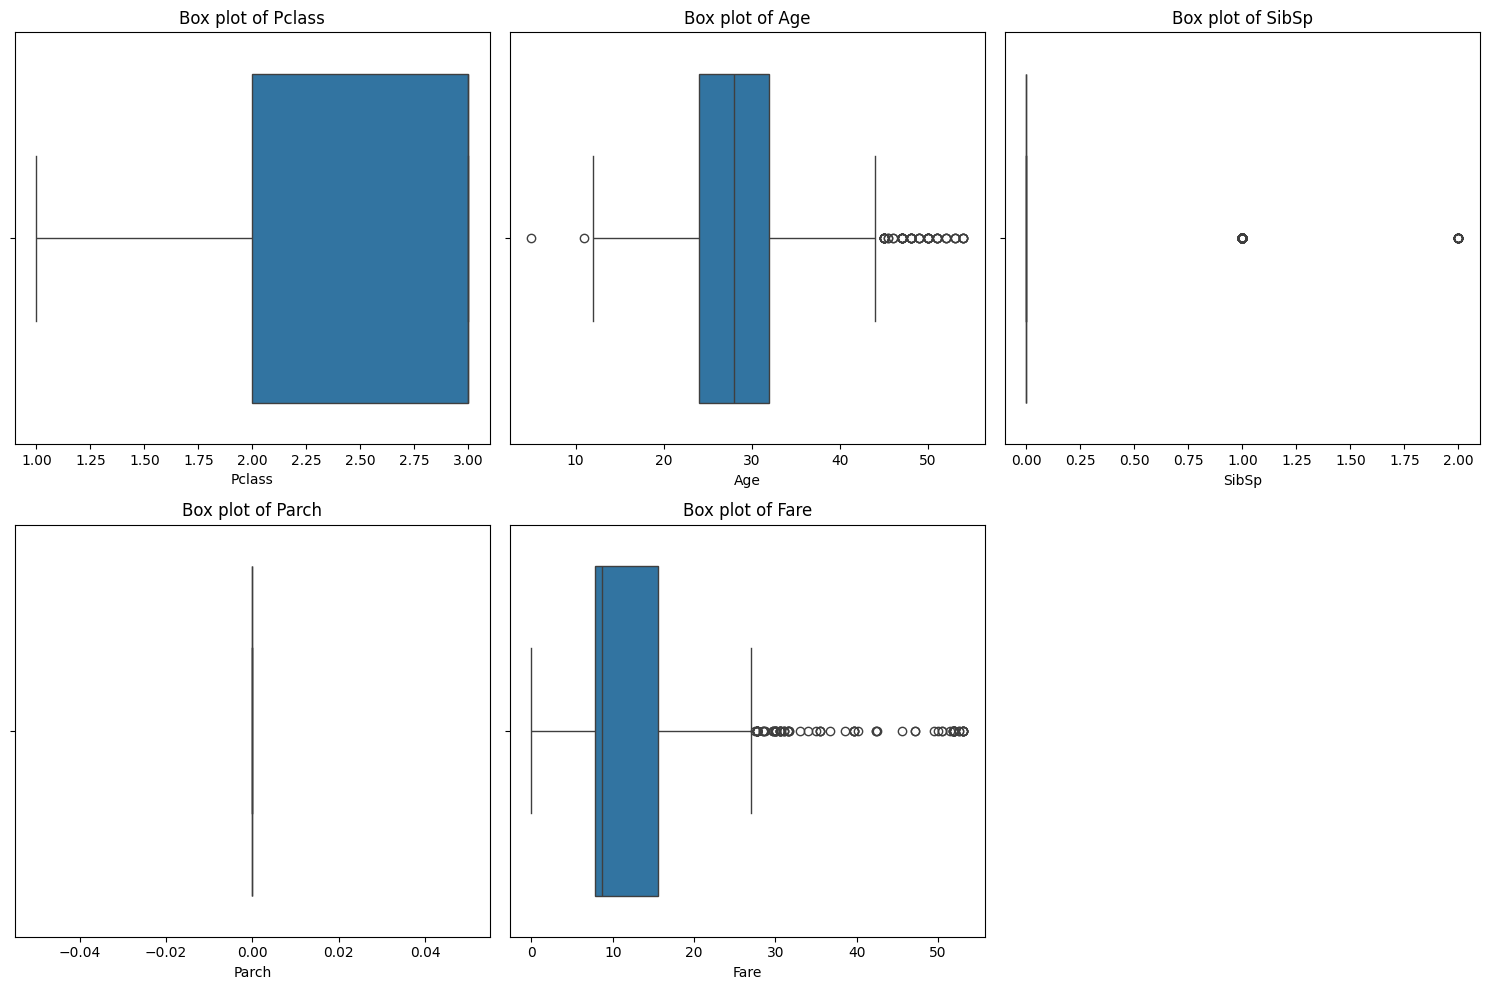

In [124]:
# AFTER DROP OUTLIERS

plt.figure(figsize=(15, 10))
for i, column in enumerate(numerical_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x=df[column])
    plt.title(f'Box plot of {column}')
plt.tight_layout()
plt.show()

## EXPLORATORY DATA ANALYSIS

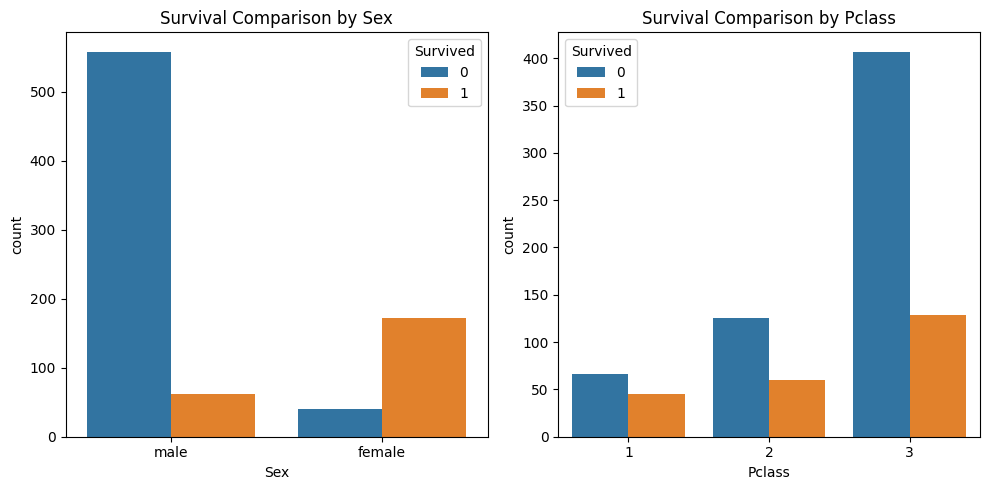

In [125]:
plt.figure(figsize=(10, 5))
eda_cols = ['Sex', 'Pclass']

for i, column in enumerate(eda_cols, 1):
    plt.subplot(1, 2, i)
    sns.countplot(x=df[column], hue=df['Survived'])
    plt.title(f"Survival Comparison by {column}")

plt.tight_layout()
plt.show()

## STANDARDIZATION

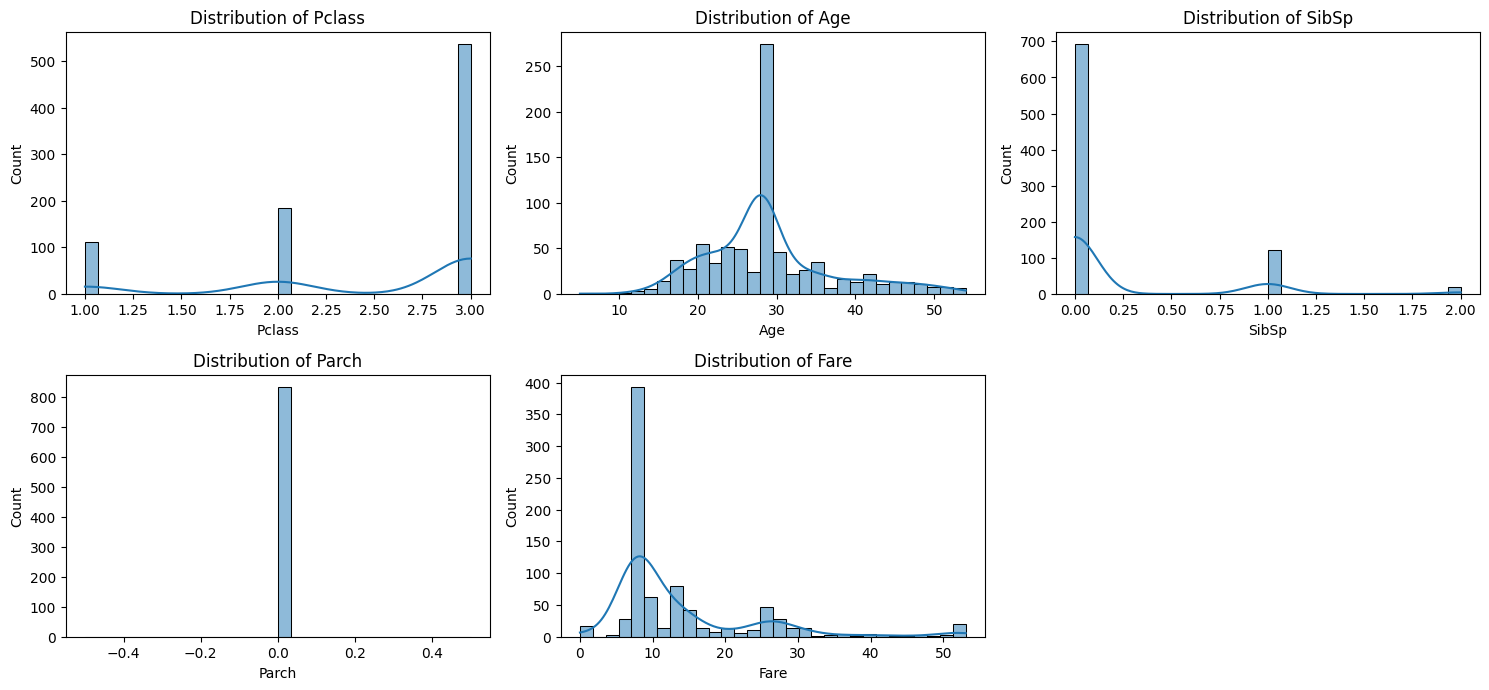

In [126]:
# BEFORE STANDARDIZATION

# NUMERICAL COLUMN
plt.figure(figsize=(15, 10))
for i, column in enumerate(numerical_cols, 1):
    plt.subplot(3, 3, i)
    sns.histplot(df[column], bins=30, kde=True)
    plt.title(f"Distribution of {column}")
plt.tight_layout()
plt.show()

C:\Users\tabiz\AppData\Local\Temp\ipykernel_1716\47839955.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[column], palette='viridis')
C:\Users\tabiz\AppData\Local\Temp\ipykernel_1716\47839955.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[column], palette='viridis')


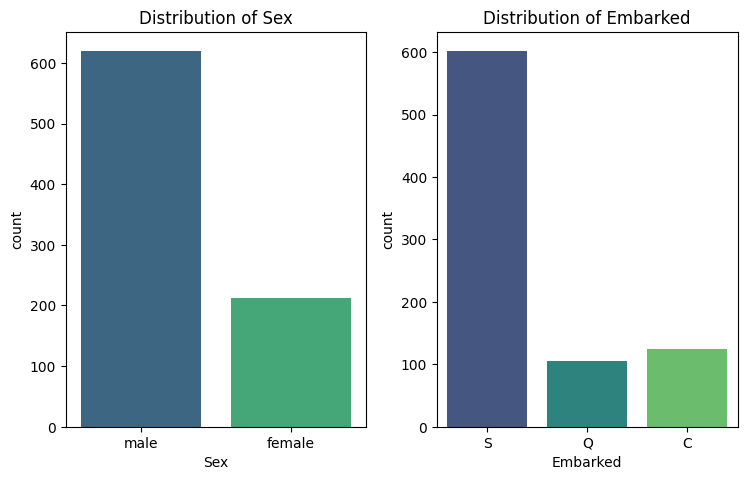

In [127]:
# CATEGORICAL COLUMN

plt.figure(figsize=(15, 9))
for i, column in enumerate(categorical_cols, 1):
    plt.subplot(2, 4, i)
    sns.countplot(x=df[column], palette='viridis')
    plt.title(f"Distribution of {column}")
plt.tight_layout()
plt.show()

In [128]:
# SCALING
scaler = StandardScaler()

df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

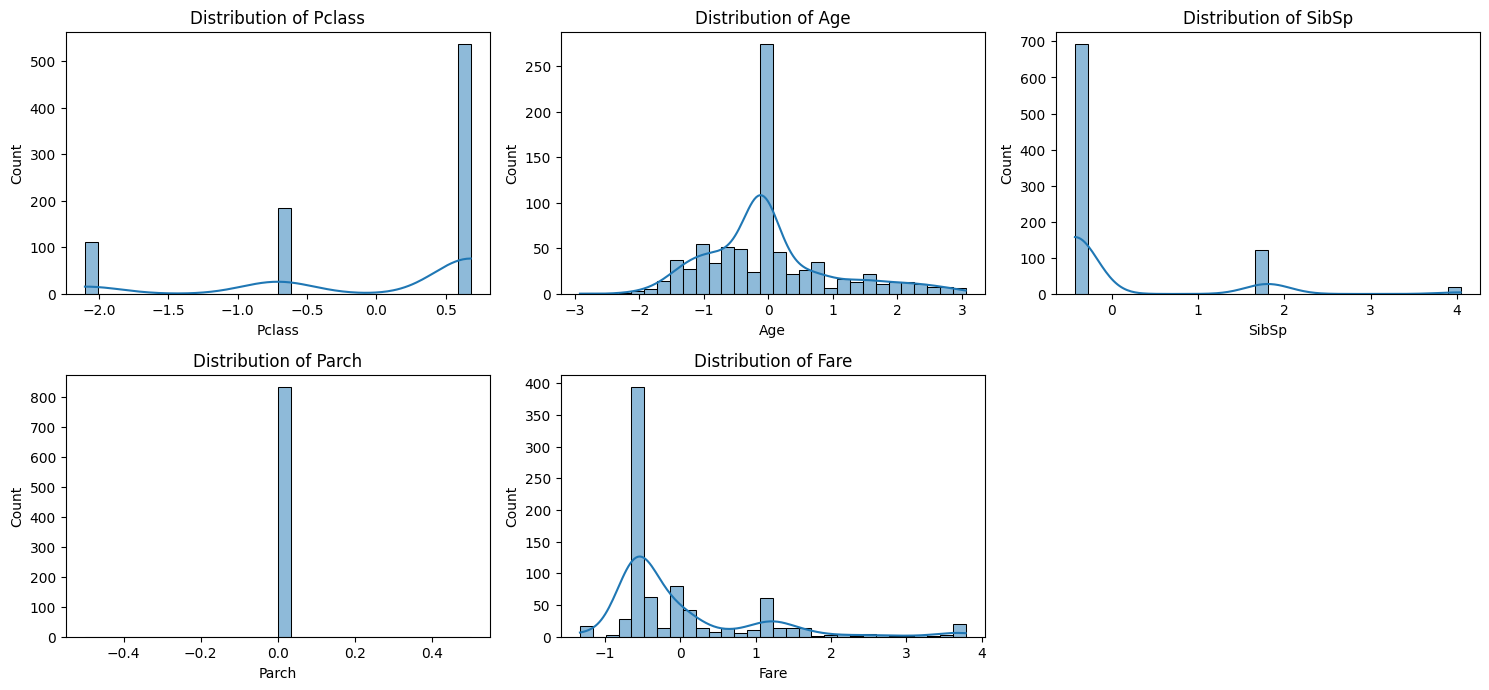

In [129]:
# AFTER STANDARDIZATION
plt.figure(figsize=(15, 10))
for i, column in enumerate(numerical_cols, 1):
    plt.subplot(3, 3, i)
    sns.histplot(df[column], bins=30, kde=True)
    plt.title(f"Distribution of {column}")
plt.tight_layout()
plt.show()

## DATA TYPE CONVERSION

In [130]:
# BEFORE ENCODING
df.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Survived
0,0.680531,male,-0.845736,1.807580,0.0,-0.634753,S,0
2,0.680531,female,-0.357470,-0.427051,0.0,-0.569626,S,1
3,-2.101786,female,0.741129,1.807580,0.0,3.789079,S,1
4,0.680531,male,0.741129,-0.427051,0.0,-0.557565,S,0
5,0.680531,male,-0.113337,-0.427051,0.0,-0.518171,Q,0


In [131]:
label_encoder = LabelEncoder()

for col in categorical_cols:
    df[col] = label_encoder.fit_transform(df[col])

# AFTER ENCODING
df.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Survived
0,0.680531,1,-0.845736,1.807580,0.0,-0.634753,2,0
2,0.680531,0,-0.357470,-0.427051,0.0,-0.569626,2,1
3,-2.101786,0,0.741129,1.807580,0.0,3.789079,2,1
4,0.680531,1,0.741129,-0.427051,0.0,-0.557565,2,0
5,0.680531,1,-0.113337,-0.427051,0.0,-0.518171,1,0


# DATA SPLIT

In [132]:
x = df.drop('Survived', axis=1)
y = df['Survived'].astype(int)

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

print("Jumlah Data:",len(x))
print("Jumlah Data Train:",len(x_train))
print("Jumlah Data Test:",len(x_test))

Jumlah Data: 832
Jumlah Data Train: 665
Jumlah Data Test: 167


# MODEL TRAINING

In [133]:
model = DecisionTreeClassifier().fit(x_train, y_train)

# MODEL TEST & EVALUATION

## CONFUSION MATRIX

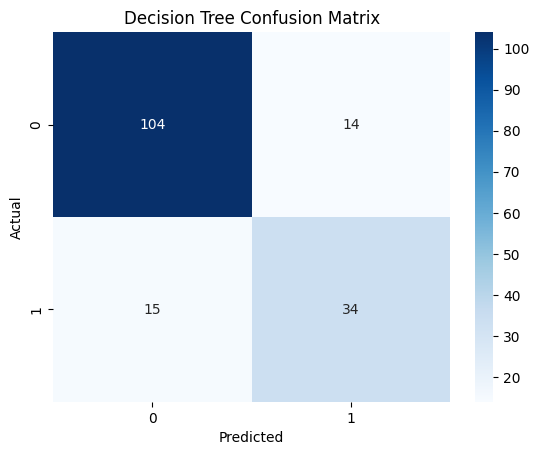

In [134]:
y_pred = model.predict(x_test)

cm = confusion_matrix(y_test, y_pred)

plt.Figure(figsize=(10, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree Confusion Matrix")
plt.show()

## EVALUATION SCORE

In [135]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Decision Tree Model Evaluation Score\n")

print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-Score: {f1:.2f}")

Decision Tree Model Evaluation Score

Accuracy: 0.83
Precision: 0.71
Recall: 0.69
F1-Score: 0.70


# HYPERPARAMETER TUNING

## RANDOM SEARCH

In [136]:
from sklearn.model_selection import RandomizedSearchCV

params = {
    'max_depth': [5, 10, 20, 30],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [2, 4, 8, 10],
    'criterion': ['gini', 'entropy'],
}

random_search = RandomizedSearchCV(estimator=model, param_distributions=params, n_iter=20, cv=3, n_jobs=-1, verbose=2, random_state=42)
random_search.fit(x_train, y_train)

print(f"Best parameters (random search): {random_search.best_params_}")
best_dt_random = random_search.best_estimator_

random_search_score = best_dt_random.score(x_test, y_test)
print(f"Accuracy after random search: {random_search_score}")

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best parameters (random search): {'min_samples_split': 2, 'min_samples_leaf': 8, 'max_depth': 20, 'criterion': 'entropy'}
Accuracy after random search: 0.8982035928143712


## CONFUSION MATRIX (AFTER TUNING)

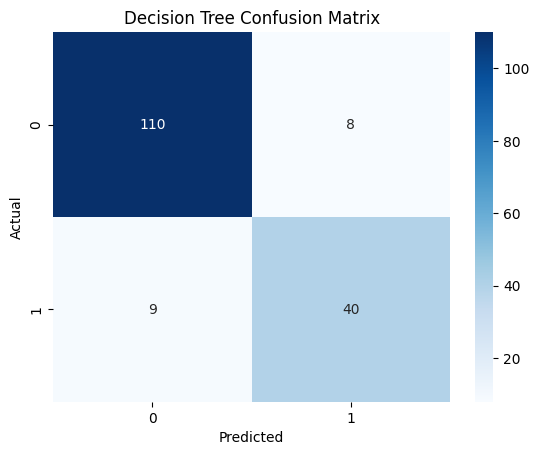

In [137]:
y_pred_tuned = random_search.predict(x_test)

cm_tuned = confusion_matrix(y_test, y_pred_tuned)

plt.Figure(figsize=(10, 6))
sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree Confusion Matrix")
plt.show()

## EVALUATION SCORE (AFTER TUNING)

In [138]:
accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
precision_tuned = precision_score(y_test, y_pred_tuned)
recall_tuned = recall_score(y_test, y_pred_tuned)
f1_tuned = f1_score(y_test, y_pred_tuned)

print("Decision Tree Model Evaluation Score (After Tuning)\n")

print(f"Accuracy: {accuracy_tuned:.2f}")
print(f"Precision: {precision_tuned:.2f}")
print(f"Recall: {recall_tuned:.2f}")
print(f"F1-Score: {f1_tuned:.2f}")

Decision Tree Model Evaluation Score (After Tuning)

Accuracy: 0.90
Precision: 0.83
Recall: 0.82
F1-Score: 0.82
